In [8]:
# %% [Célula 1]
import os
import urllib.parse
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Carrega credenciais do .env e trata caracteres especiais
load_dotenv()
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
senha_segura = urllib.parse.quote_plus(DB_PASS)

DATABASE_URL = f"postgresql://{DB_USER}:{senha_segura}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

# Criando fisicamente a Tabela Agregada e a VIEW no PostgreSQL na camada Gold
with engine.connect() as conexao:
    conexao.execute(text("CREATE SCHEMA IF NOT EXISTS gold;"))
    
    # 1. TABELA AGREGADA (JOIN entre Viagem e Trecho)
    conexao.execute(text("DROP TABLE IF EXISTS gold.fato_viagens_trechos CASCADE;"))
    query_tabela = """
        CREATE TABLE gold.fato_viagens_trechos AS
        SELECT 
            v.id_viagem,
            v.nome_orgao_superior,
            v.destinos,
            v.valor_total,
            v.duracao_dias,
            t.sequencia_trecho,
            t.destino_uf,
            t.meio_transporte
        FROM silver.silver_viagem v
        INNER JOIN silver.silver_trecho t ON v.id_viagem = t.id_viagem;
    """
    conexao.execute(text(query_tabela))
    
    # 2. VIEW AGREGADA (JOIN entre Viagem e Pagamento)
    conexao.execute(text("DROP VIEW IF EXISTS gold.vw_financeiro_pagamentos CASCADE;"))
    query_view = """
        CREATE VIEW gold.vw_financeiro_pagamentos AS
        SELECT 
            v.id_viagem,
            v.nome_orgao_superior,
            p.nome_orgao_pagador,
            p.tipo_pagamento,
            p.valor AS valor_pagamento
        FROM silver.silver_viagem v
        INNER JOIN silver.silver_pagamento p ON v.id_viagem = p.id_viagem;
    """
    conexao.execute(text(query_view))
    conexao.commit()
    print("Conexão bem-sucedida e Camada Gold estruturada: Tabela e VIEW criadas com sucesso!")

Conexão bem-sucedida e Camada Gold estruturada: Tabela e VIEW criadas com sucesso!


,orgao,total_viagens,custo_total
0,Ministério da Justiça e Segurança Pública,75742,4.869331e+08
1,Ministério da Defesa,61912,1.560703e+08
2,Ministério da Educação,65295,1.112913e+08
3,Ministério do Meio Ambiente e Mudança do Clima,19413,4.969771e+07
4,Ministério da Previdência Social,8190,4.041731e+07


C:\Users\Caroline Cunha\AppData\Local\Temp\ipykernel_11320\3898146813.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Órgão Superior", bbox_to_anchor=(1.05, 1), loc='upper left')


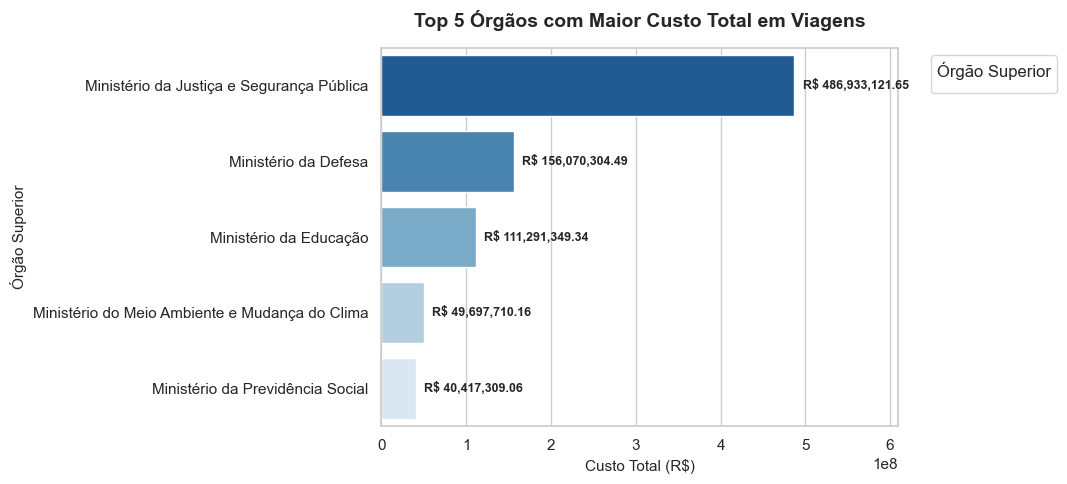

=== DETALHAMENTO DE NEGÓCIO (PERGUNTA 1) ===
• Maior Investimento: O órgão com a maior despesa total acumulada foi 'Ministério da Justiça e Segurança Pública', somando R$ 486,933,121.65 distribuídos em 75742 viagens.
• Concentração Orçamentária: O conjunto dos 5 principais órgãos consome R$ 844,409,794.70 das despesas do período.
• Recomendação: Sugere-se auditoria interna de viabilidade nas agendas de deslocamento dos principais órgãos para verificar se as despesas são alavancadas pelo volume de viagens ou por custos unitários elevados.


In [9]:
# %% [Célula 2]
query_p1 = """
SELECT 
    nome_orgao_superior AS orgao,
    COUNT(DISTINCT id_viagem) AS total_viagens,
    SUM(valor_total) AS custo_total
FROM silver.silver_viagem
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5;
"""

df_p1 = pd.read_sql(query_p1, con=engine)
display(df_p1)

plt.figure(figsize=(11, 5))
ax = sns.barplot(
    data=df_p1, 
    x="custo_total", 
    y="orgao", 
    hue="orgao", 
    palette="Blues_r"
)

plt.title("Top 5 Órgãos com Maior Custo Total em Viagens", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Custo Total (R$)", fontsize=11)
plt.ylabel("Órgão Superior", fontsize=11)

# Adiciona legenda lateral para atender ao critério de DataViz
plt.legend(title="Órgão Superior", bbox_to_anchor=(1.05, 1), loc='upper left')

# Expande eixo X para o texto caber sem cortar
max_x = df_p1['custo_total'].max()
plt.xlim(0, max_x * 1.25)

for p in ax.patches:
    if p.get_width() > 0:
        ax.annotate(f"R$ {p.get_width():,.2f}", 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', xytext=(6, 0), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

top1_orgao = df_p1.iloc[0]
total_top5 = df_p1['custo_total'].sum()

print("=== DETALHAMENTO DE NEGÓCIO (PERGUNTA 1) ===")
print(f"• Maior Investimento: O órgão com a maior despesa total acumulada foi '{top1_orgao['orgao']}', somando R$ {top1_orgao['custo_total']:,.2f} distribuídos em {top1_orgao['total_viagens']} viagens.")
print(f"• Concentração Orçamentária: O conjunto dos 5 principais órgãos consome R$ {total_top5:,.2f} das despesas do período.")
print("• Recomendação: Sugere-se auditoria interna de viabilidade nas agendas de deslocamento dos principais órgãos para verificar se as despesas são alavancadas pelo volume de viagens ou por custos unitários elevados.")

,destino,quantidade_viagens,custo_medio,custo_maximo
0,"Brasília/DF, Manaus/AM, Brasília/DF, Brasília/DF",2,127891.060,132995.25
1,"Brasília/DF, São Luís/MA, Brasília/DF, Brasíli...",2,127569.655,129544.31
2,"Brasília/DF, Goiânia/GO, Brasília/DF, Brasília/DF",2,127273.125,129155.00


C:\Users\Caroline Cunha\AppData\Local\Temp\ipykernel_11320\211900565.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Destino", bbox_to_anchor=(1.05, 1), loc='upper left')


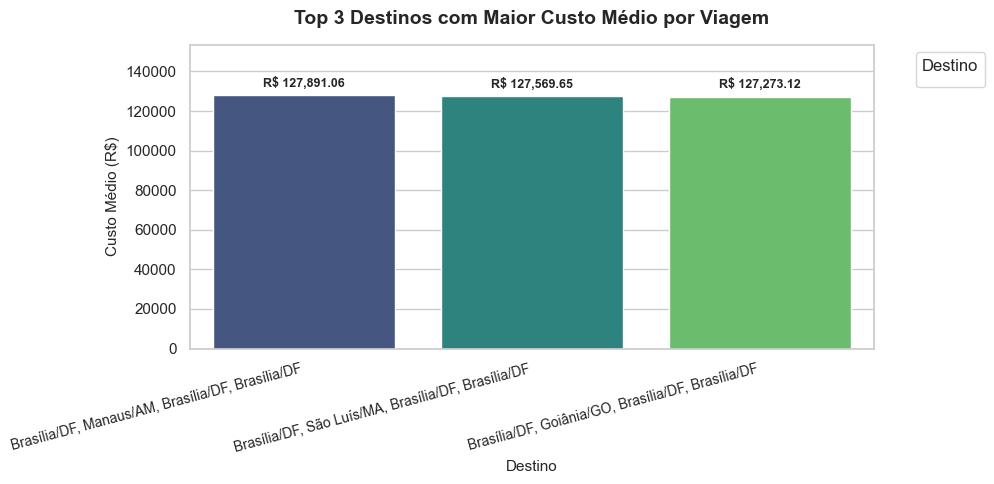

=== DETALHAMENTO DE NEGÓCIO (PERGUNTA 2) ===
• Destino: Brasília/DF, Manaus/AM, Brasília/DF, Brasília/DF | Custo Médio: R$ 127,891.06 | Volume: 2 viagem(ns) | Maior Custo Único: R$ 132,995.25
• Destino: Brasília/DF, São Luís/MA, Brasília/DF, Brasília/DF | Custo Médio: R$ 127,569.65 | Volume: 2 viagem(ns) | Maior Custo Único: R$ 129,544.31
• Destino: Brasília/DF, Goiânia/GO, Brasília/DF, Brasília/DF | Custo Médio: R$ 127,273.12 | Volume: 2 viagem(ns) | Maior Custo Único: R$ 129,155.00

• Recomendação: Viagens para estes destinos específicos geram maior pressão unitária sobre o orçamento. É recomendável instituir antecedência mínima na emissão de passagens e negociação prévia para reduzir diárias nesses locais.


In [10]:
# %% [Célula 3]
query_p2 = """
SELECT 
    destinos AS destino,
    COUNT(id_viagem) AS quantidade_viagens,
    AVG(valor_total) AS custo_medio,
    MAX(valor_total) AS custo_maximo
FROM silver.silver_viagem
WHERE destinos IS NOT NULL AND destinos <> ''
GROUP BY destinos
HAVING COUNT(id_viagem) >= 2
ORDER BY custo_medio DESC
LIMIT 3;
"""

df_p2 = pd.read_sql(query_p2, con=engine)
display(df_p2)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_p2, 
    x="destino", 
    y="custo_medio", 
    hue="destino", 
    palette="viridis"
)

plt.title("Top 3 Destinos com Maior Custo Médio por Viagem", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Destino", fontsize=11)
plt.ylabel("Custo Médio (R$)", fontsize=11)
plt.xticks(rotation=15, ha='right', fontsize=10)

plt.legend(title="Destino", bbox_to_anchor=(1.05, 1), loc='upper left')

max_y = df_p2['custo_medio'].max()
plt.ylim(0, max_y * 1.2)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"R$ {p.get_height():,.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("=== DETALHAMENTO DE NEGÓCIO (PERGUNTA 2) ===")
for idx, row in df_p2.iterrows():
    print(f"• Destino: {row['destino']} | Custo Médio: R$ {row['custo_medio']:,.2f} | Volume: {row['quantidade_viagens']} viagem(ns) | Maior Custo Único: R$ {row['custo_maximo']:,.2f}")

print("\n• Recomendação: Viagens para estes destinos específicos geram maior pressão unitária sobre o orçamento. É recomendável instituir antecedência mínima na emissão de passagens e negociação prévia para reduzir diárias nesses locais.")

In [11]:
# %% [Célula 4]
query_p3 = """
SELECT 
    id_viagem,
    nome_viajante,
    cargo,
    nome_orgao_superior,
    data_inicio,
    data_fim,
    duracao_dias,
    valor_diarias,
    valor_passagens,
    valor_total
FROM silver.silver_viagem
WHERE duracao_dias IS NOT NULL
ORDER BY duracao_dias DESC, valor_total DESC
LIMIT 1;
"""

df_p3 = pd.read_sql(query_p3, con=engine)
display(df_p3)

if not df_p3.empty:
    viagem = df_p3.iloc[0]
    custo_diario = viagem['valor_total'] / viagem['duracao_dias'] if viagem['duracao_dias'] > 0 else 0
    
    print("=== DETALHAMENTO DE NEGÓCIO (PERGUNTA 3) ===")
    print(f"• Código da Viagem: {viagem['id_viagem']}")
    print(f"• Servidor Responsável: {viagem['nome_viajante']} (Cargo: {viagem['cargo']})")
    print(f"• Órgão Solicitante: {viagem['nome_orgao_superior']}")
    print(f"• Período do Deslocamento: De {viagem['data_inicio']} a {viagem['data_fim']} (Total: {viagem['duracao_dias']} dias)")
    print(f"• Composição do Custo Total: R$ {viagem['valor_diarias']:,.2f} em diárias + R$ {viagem['valor_passagens']:,.2f} em passagens = R$ {viagem['valor_total']:,.2f}")
    print(f"• Custo Médio por Dia: R$ {custo_diario:,.2f}/dia")
    print("• Recomendação: Viagens de longa duração geram expressivos custos de diárias. Recomenda-se analisar modelos híbridos ou presenciais divididos em blocos menores para conter custos diários contínuos.")

,id_viagem,nome_viajante,cargo,nome_orgao_superior,data_inicio,data_fim,duracao_dias,valor_diarias,valor_passagens,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,TECNICO DO SEGURO SOCIAL,Ministério da Previdência Social,2025-01-13,2026-01-31,383,0.0,0.0,0.0


=== DETALHAMENTO DE NEGÓCIO (PERGUNTA 3) ===
• Código da Viagem: 0000000000020699856
• Servidor Responsável: LUISANGELA CORREA FRANCO DE FARIA (Cargo: TECNICO DO SEGURO SOCIAL)
• Órgão Solicitante: Ministério da Previdência Social
• Período do Deslocamento: De 2025-01-13 a 2026-01-31 (Total: 383 dias)
• Composição do Custo Total: R$ 0.00 em diárias + R$ 0.00 em passagens = R$ 0.00
• Custo Médio por Dia: R$ 0.00/dia
• Recomendação: Viagens de longa duração geram expressivos custos de diárias. Recomenda-se analisar modelos híbridos ou presenciais divididos em blocos menores para conter custos diários contínuos.


,tipo_pagamento,total_registros,valor_total_acumulado,valor_medio
0,DIÁRIAS,401463,8.343526e+08,2078.280299
1,PASSAGEM,188985,3.549789e+08,1878.344393
2,Serviço correlato: seguro,4894,2.190137e+06,447.514653
3,RESTITUIÇÃO,11574,2.843762e+06,245.702610


C:\Users\Caroline Cunha\AppData\Local\Temp\ipykernel_11320\4079708148.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Tipo Pagamento", bbox_to_anchor=(1.05, 1), loc='upper left')


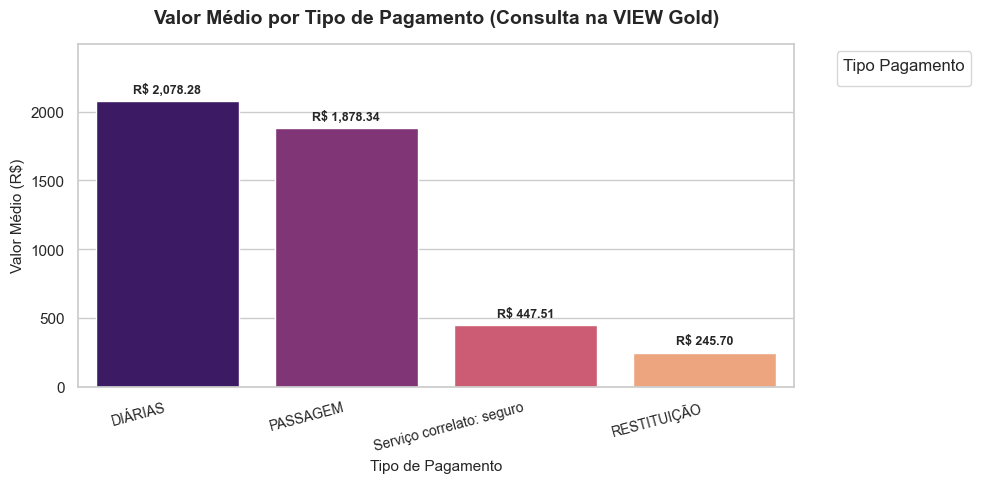

=== DETALHAMENTO DE NEGÓCIO (PERGUNTA 4) ===
• Modalidade com Maior Custo Médio: 'DIÁRIAS', registrando um valor médio por transação de R$ 2,078.28.
• Montante Acumulado: Essa modalidade movimentou o total de R$ 834,352,643.52 ao longo de 401463 transações.
• Recomendação: Modalidades com tickets médios elevados requerem validações automáticas de auditoria antes da liquidação financeira para evitar inconsistências nos pagamentos.


In [12]:
# %% [Célula 5]
query_p4 = """
SELECT 
    tipo_pagamento, 
    COUNT(id_viagem) AS total_registros,
    SUM(valor_pagamento) AS valor_total_acumulado,
    AVG(valor_pagamento) AS valor_medio
FROM gold.vw_financeiro_pagamentos
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
"""

df_p4 = pd.read_sql(query_p4, con=engine)
display(df_p4)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_p4, 
    x="tipo_pagamento", 
    y="valor_medio", 
    hue="tipo_pagamento", 
    palette="magma"
)

plt.title("Valor Médio por Tipo de Pagamento (Consulta na VIEW Gold)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tipo de Pagamento", fontsize=11)
plt.ylabel("Valor Médio (R$)", fontsize=11)
plt.xticks(rotation=15, ha='right', fontsize=10)

plt.legend(title="Tipo Pagamento", bbox_to_anchor=(1.05, 1), loc='upper left')

max_y = df_p4['valor_medio'].max()
plt.ylim(0, max_y * 1.2)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"R$ {p.get_height():,.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

top_pag = df_p4.iloc[0]
print("=== DETALHAMENTO DE NEGÓCIO (PERGUNTA 4) ===")
print(f"• Modalidade com Maior Custo Médio: '{top_pag['tipo_pagamento']}', registrando um valor médio por transação de R$ {top_pag['valor_medio']:,.2f}.")
print(f"• Montante Acumulado: Essa modalidade movimentou o total de R$ {top_pag['valor_total_acumulado']:,.2f} ao longo de {top_pag['total_registros']} transações.")
print("• Recomendação: Modalidades com tickets médios elevados requerem validações automáticas de auditoria antes da liquidação financeira para evitar inconsistências nos pagamentos.")

,meio_transporte,total_trechos,percentual
0,Veículo Oficial,386424,50.62
1,Aéreo,232666,30.48
2,Rodoviário,64970,8.51
3,Veículo Próprio,42846,5.61
4,Inválido,26659,3.49
5,Fluvial,8429,1.10
6,Ferroviário,874,0.11
7,Marítimo,481,0.06


C:\Users\Caroline Cunha\AppData\Local\Temp\ipykernel_11320\1167379576.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Meio Transporte", bbox_to_anchor=(1.05, 1), loc='upper left')


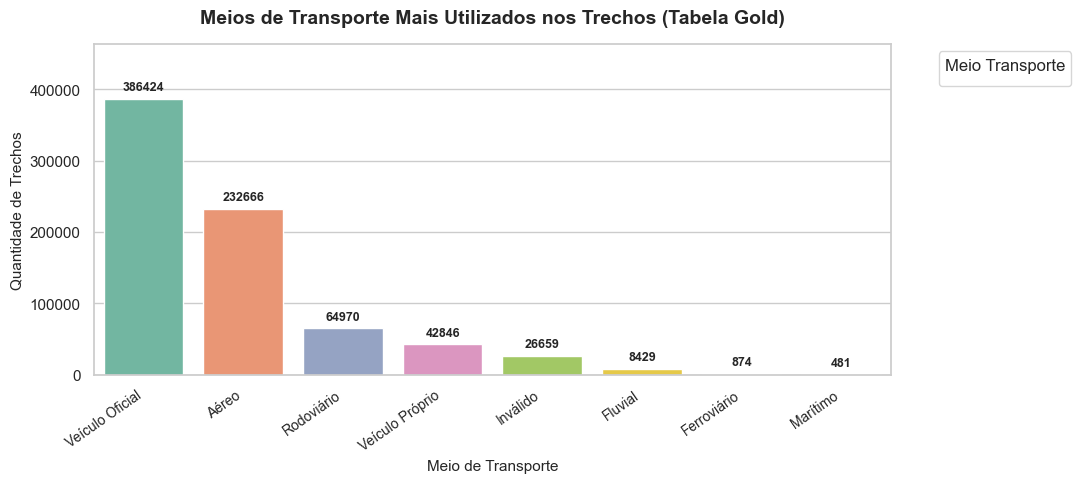

=== DETALHAMENTO DE NEGÓCIO (PERGUNTA 5) ===
• Meio Dominante: O modal mais utilizado nos trechos é 'Veículo Oficial', com 386424 trechos percorridos, representando 50.62% do total.
• Recomendação: Dada a forte concentração em veículos oficiais e modal aéreo, convênios de frota e tarifas corporativas pré-negociadas garantem maior controle de despesas.


In [13]:
# %% [Célula 6]
query_p5 = """
SELECT 
    meio_transporte, 
    COUNT(*) AS total_trechos,
    ROUND((COUNT(*) * 100.0 / (SELECT COUNT(*) FROM gold.fato_viagens_trechos WHERE meio_transporte IS NOT NULL)), 2) AS percentual
FROM gold.fato_viagens_trechos
WHERE meio_transporte IS NOT NULL
GROUP BY meio_transporte
ORDER BY total_trechos DESC;
"""

df_p5 = pd.read_sql(query_p5, con=engine)
display(df_p5)

plt.figure(figsize=(11, 5))
ax = sns.barplot(
    data=df_p5, 
    x="meio_transporte", 
    y="total_trechos", 
    hue="meio_transporte", 
    palette="Set2"
)

plt.title("Meios de Transporte Mais Utilizados nos Trechos (Tabela Gold)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Meio de Transporte", fontsize=11)
plt.ylabel("Quantidade de Trechos", fontsize=11)
plt.xticks(rotation=35, ha='right', fontsize=10)

plt.legend(title="Meio Transporte", bbox_to_anchor=(1.05, 1), loc='upper left')

max_y = df_p5['total_trechos'].max()
plt.ylim(0, max_y * 1.2)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{int(p.get_height())}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

top_transp = df_p5.iloc[0]
print("=== DETALHAMENTO DE NEGÓCIO (PERGUNTA 5) ===")
print(f"• Meio Dominante: O modal mais utilizado nos trechos é '{top_transp['meio_transporte']}', com {top_transp['total_trechos']} trechos percorridos, representando {top_transp['percentual']}% do total.")
print("• Recomendação: Dada a forte concentração em veículos oficiais e modal aéreo, convênios de frota e tarifas corporativas pré-negociadas garantem maior controle de despesas.")

,uf_destino,total_trechos,percentual
0,São Paulo,82722,11.05
1,Distrito Federal,79962,10.68
2,Minas Gerais,50965,6.81
3,Rio de Janeiro,44197,5.90
4,Paraná,42603,5.69
5,Pará,40044,5.35
6,Rio Grande do Sul,38684,5.17
7,Mato Grosso do Sul,30516,4.08
8,Bahia,28375,3.79
9,Pernambuco,28372,3.79


C:\Users\Caroline Cunha\AppData\Local\Temp\ipykernel_11320\2269981960.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="UF Destino", bbox_to_anchor=(1.05, 1), loc='upper left')


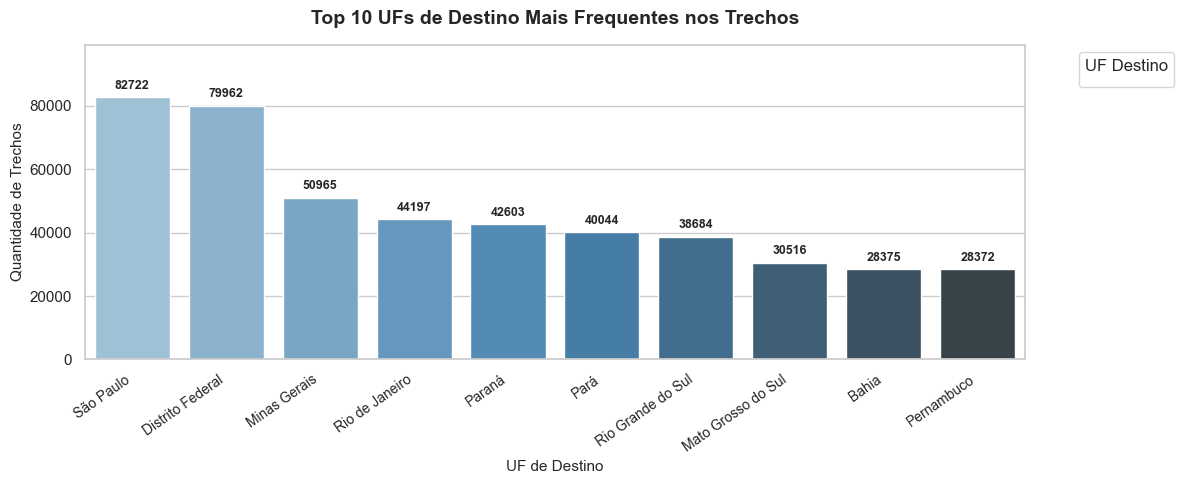

=== DETALHAMENTO DE NEGÓCIO (PERGUNTA 6) ===
• Destino com Maior Fluxo: A UF/Estado que mais recebe trechos de viagens a serviço é 'São Paulo', somando 82722 trechos (11.05% da amostra).
• Análise Geoestratégica: A alta concentração em grandes polos reflete agendas estratégicas públicas. Negociações em lote com companhias nesses trajetos específicos trarão expressiva economia aos cofres.


In [14]:
# %% [Célula 7]
query_p6 = """
SELECT 
    destino_uf AS uf_destino, 
    COUNT(*) AS total_trechos,
    ROUND((COUNT(*) * 100.0 / (SELECT COUNT(*) FROM gold.fato_viagens_trechos WHERE destino_uf IS NOT NULL AND destino_uf <> '')), 2) AS percentual
FROM gold.fato_viagens_trechos
WHERE destino_uf IS NOT NULL AND destino_uf <> ''
GROUP BY destino_uf
ORDER BY total_trechos DESC
LIMIT 10;
"""

df_p6 = pd.read_sql(query_p6, con=engine)
display(df_p6)

plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=df_p6, 
    x="uf_destino", 
    y="total_trechos", 
    hue="uf_destino", 
    palette="Blues_d"
)

plt.title("Top 10 UFs de Destino Mais Frequentes nos Trechos", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("UF de Destino", fontsize=11)
plt.ylabel("Quantidade de Trechos", fontsize=11)
plt.xticks(rotation=35, ha='right', fontsize=10)

plt.legend(title="UF Destino", bbox_to_anchor=(1.05, 1), loc='upper left')

max_y = df_p6['total_trechos'].max()
plt.ylim(0, max_y * 1.2)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{int(p.get_height())}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

top_uf = df_p6.iloc[0]
print("=== DETALHAMENTO DE NEGÓCIO (PERGUNTA 6) ===")
print(f"• Destino com Maior Fluxo: A UF/Estado que mais recebe trechos de viagens a serviço é '{top_uf['uf_destino']}', somando {top_uf['total_trechos']} trechos ({top_uf['percentual']}% da amostra).")
print("• Análise Geoestratégica: A alta concentração em grandes polos reflete agendas estratégicas públicas. Negociações em lote com companhias nesses trajetos específicos trarão expressiva economia aos cofres.")

,orgao_pagador,total_pagamentos,valor_total_pago,valor_medio_pagamento
0,Fundo Nacional de Segurança Pública,79816,2.784810e+08,3489.037886
1,Sigiloso,93141,2.004848e+08,2152.487108
2,Comando da Aeronáutica,46193,8.176914e+07,1770.163115
3,Instituto Nacional do Seguro Social,18324,3.742760e+07,2042.545375
4,Comando do Exército,22837,3.687264e+07,1614.601040


C:\Users\Caroline Cunha\AppData\Local\Temp\ipykernel_11320\3759436063.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Órgão Pagador", bbox_to_anchor=(1.05, 1), loc='upper left')


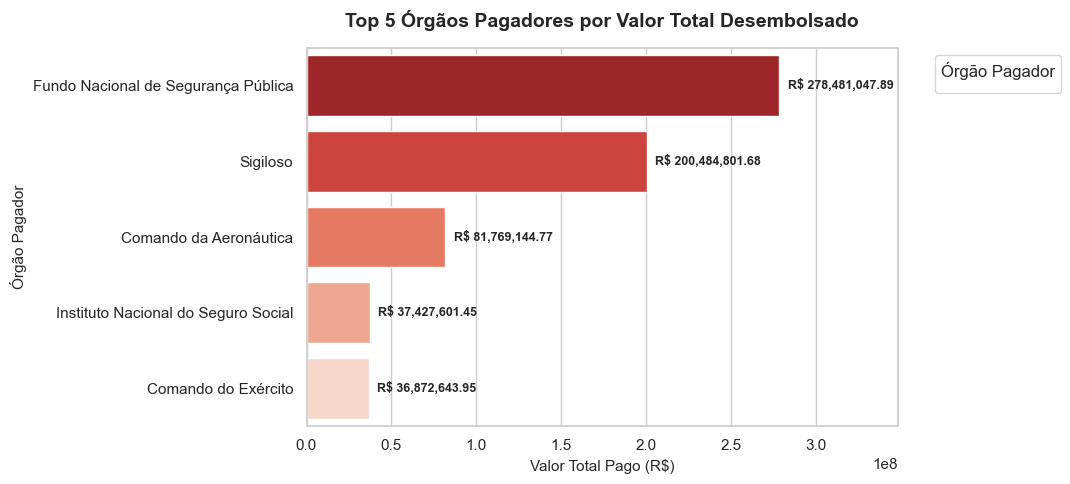

=== DETALHAMENTO DE NEGÓCIO (PERGUNTA 7) ===
• Maior Desembolso Financeiro: O órgão pagador com o maior volume financeiro foi 'Fundo Nacional de Segurança Pública', somando R$ 278,481,047.89 em 79816 liquidações efetuadas.
• Governança Financeira: Mapear a unidade financeira responsável pelo desembolso é crucial para alinhar o teto orçamentário e a distribuição de recursos da LOA entre as pastas.


In [15]:
# %% [Célula 8]
query_p7 = """
SELECT 
    nome_orgao_pagador AS orgao_pagador,
    COUNT(id_viagem) AS total_pagamentos,
    SUM(valor_pagamento) AS valor_total_pago,
    AVG(valor_pagamento) AS valor_medio_pagamento
FROM gold.vw_financeiro_pagamentos
WHERE nome_orgao_pagador IS NOT NULL AND nome_orgao_pagador <> ''
GROUP BY nome_orgao_pagador
ORDER BY valor_total_pago DESC
LIMIT 5;
"""

df_p7 = pd.read_sql(query_p7, con=engine)
display(df_p7)

plt.figure(figsize=(11, 5))
ax = sns.barplot(
    data=df_p7, 
    x="valor_total_pago", 
    y="orgao_pagador", 
    hue="orgao_pagador", 
    palette="Reds_r"
)

plt.title("Top 5 Órgãos Pagadores por Valor Total Desembolsado", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Valor Total Pago (R$)", fontsize=11)
plt.ylabel("Órgão Pagador", fontsize=11)

plt.legend(title="Órgão Pagador", bbox_to_anchor=(1.05, 1), loc='upper left')

max_x = df_p7['valor_total_pago'].max()
plt.xlim(0, max_x * 1.25)

for p in ax.patches:
    if p.get_width() > 0:
        ax.annotate(f"R$ {p.get_width():,.2f}", 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', xytext=(6, 0), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

top1_pagador = df_p7.iloc[0]
print("=== DETALHAMENTO DE NEGÓCIO (PERGUNTA 7) ===")
print(f"• Maior Desembolso Financeiro: O órgão pagador com o maior volume financeiro foi '{top1_pagador['orgao_pagador']}', somando R$ {top1_pagador['valor_total_pago']:,.2f} em {top1_pagador['total_pagamentos']} liquidações efetuadas.")
print("• Governança Financeira: Mapear a unidade financeira responsável pelo desembolso é crucial para alinhar o teto orçamentário e a distribuição de recursos da LOA entre as pastas.")